In [53]:
import numpy as np
import subprocess
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import os

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print(f"Setting root of the project to: {root}")

def alleleFrequency(base, allele_count):
    # Allele count format: [A : T : C : G : N : del]
    base_dict = {
        'A': 0,
        'T': 1,
        'C': 2,
        'G': 3,
        'N': 4,   # unused
        'del': 5  # unsued, both defined to be explicit
    }
    base_index = base_dict.get(base)
    vector = [int(num) for num in allele_count.split(':')]

    # Sum all values
    total = sum(vector)

    # Error-handle for division-by-zero
    if total == 0:
        return 0.0

    # Find difference between base & total
    base_value = vector[base_index]
    mutations = total - base_value
    freq = mutations / total
    return freq
    
def readAlleleFrequencyData(file_path="../data/chromosome_2L.sync"):
    columns = [
        'chromosome',
        'position',
        'base',
        'Dsim_Fl_Base_1',
        'Dsim_Fl_Hot_F10_1',
        'Dsim_Fl_Hot_F20_1', 
        'Dsim_Fl_Hot_F30_1',
        'Dsim_Fl_Hot_F40_1', 
        'Dsim_Fl_Hot_F50_1', 
        'Dsim_Fl_Hot_F60_1'
    ]

    df = pd.read_csv(
        filepath_or_buffer=file_path,
        sep='\t', # tab-separated values
        names=columns,
        usecols=columns,
        header=None # no headers provided
    )

    rename_dict = {
        'Dsim_Fl_Base_1':    'gen_0',
        'Dsim_Fl_Hot_F10_1': 'gen_10',
        'Dsim_Fl_Hot_F20_1': 'gen_20',
        'Dsim_Fl_Hot_F30_1': 'gen_30',
        'Dsim_Fl_Hot_F40_1': 'gen_40',
        'Dsim_Fl_Hot_F50_1': 'gen_50',
        'Dsim_Fl_Hot_F60_1': 'gen_60'
    }

    # Rename the columns (inplace=True modifies the original DataFrame)
    df.drop(columns=['chromosome'], inplace=True)
    df.rename(columns=rename_dict, inplace=True)

    for column in ['gen_0','gen_10','gen_20','gen_30','gen_40','gen_50','gen_60']:
        df[column] = [
            alleleFrequency(b, c) 
            for b, c in zip(df['base'], df[column])
        ]    

    return df    

def readSamples():
    dir_path = "../slim/outputs/"
    file_paths = []
    for filename in os.listdir(dir_path):
        full_path = os.path.join(dir_path, filename)
        if os.path.isfile(full_path):
            file_paths.append(full_path)

    df_list = []
    for file_path in file_paths:
        tmp = pd.read_csv(file_path)
        df_list.append(tmp)

    df = pd.concat(df_list, ignore_index=True)
    df.drop(inplace=True, columns=['Unnamed: 0'])
    return df

df = readSamples()
df.head()

Setting root of the project to: /home/kv/education/predicting_DFE


,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60,simdelta_20,simdelta_30,simdelta_40,simdelta_50,simdelta_60,alpha,beta
0,10194546,0.0000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,12000.666667,0.00075
1,10194549,0.0000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,12000.666667,0.00075
2,10194552,0.0000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,12000.666667,0.00075
3,10194557,0.0005,0.0,0.0,0.0,0.0,0.0,-0.0005,0.0,0.0,0.0,0.0,12000.666667,0.00075
4,10194670,0.0000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,12000.666667,0.00075


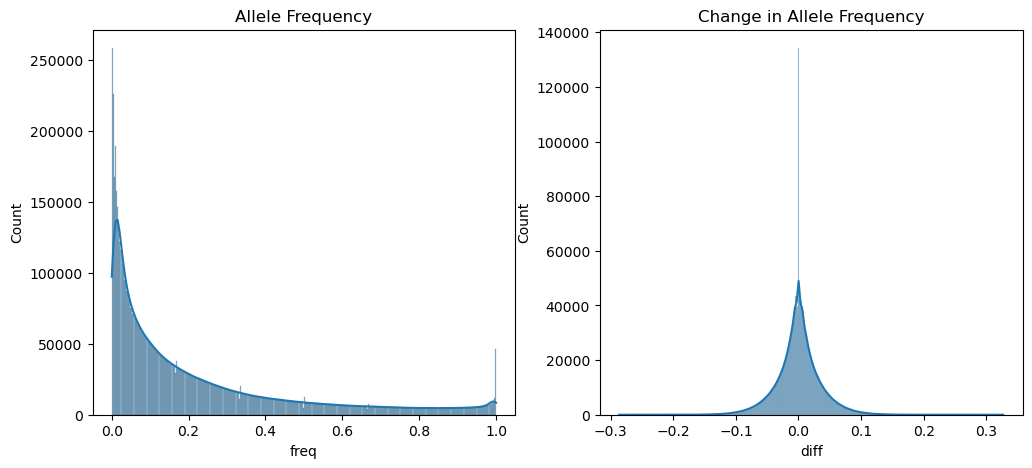

In [24]:
# Read the original data for chromosome 2L
fact = readAlleleFrequencyData()
fact = fact.melt(
    id_vars = ['position', 'base'],
    value_name = 'freq',
    var_name = 'gen'
)
fact['gen'] = fact['gen'].str.replace("gen_", "").astype(int)
fact = fact.sort_values(['position', 'gen'])
fact['diff'] = fact.groupby("position")['freq'].diff()

# Plot the frequency & change in frequency
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(ax=ax[0], data=fact, x='freq', kde=True)
ax[0].set_title("Allele Frequency")

sns.histplot(ax=ax[1], data=fact, x='diff', kde=True)
ax[1].set_title("Change in Allele Frequency")

plt.show()

In [54]:
sim = df.melt(
    id_vars = ['position', 'alpha', 'beta'],
    value_vars = ['simdelta_20', 'simdelta_30', 'simdelta_40', 'simdelta_50', 'simdelta_60'],
    var_name = 'gen',
    value_name = 'diff'
)
sim['gen'] = sim['gen'].str.replace("simdelta_", "").astype(int)

/tmp/nix-shell.TbSYsS/ipykernel_5701/1408921639.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(ax=ax[1], data=sim, x='diff', alpha=1, hue='alpha')


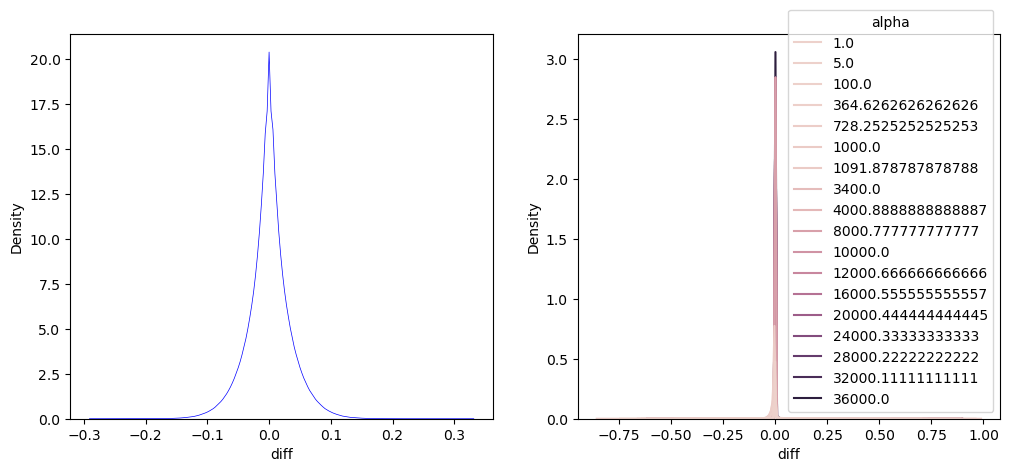

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# The real curve
sns.kdeplot(ax=ax[0], data=fact, x='diff', color='blue', alpha=1, linewidth=.5)

# Plot the simulant curves
sns.kdeplot(ax=ax[1], data=sim, x='diff', alpha=1, hue='alpha')

# sns.kdeplot(ax=ax[2], data=sim, x='diff', alpha=1, hue='beta')

# plt.title("Comparison of the real vs. simulated data")
# plt.grid(alpha=.3)
plt.show()